# Produce multi-group xs covariance matrix with NJOY with custom group structure

In [1]:
import sandy

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

The case study will be Pb206.

Since covariance data are available for many reaction channels we'll keep only:
- total (MT=1)
- elastic scattering (MT=2)
- inelastic scattering (MT=4)
- radiative capture (MT=102)

In [3]:
mts = [1, 2, 4, 102]

## Parametric variation of the group structure

In [4]:
kws = dict(chi=False, mubar=False)

First, we produce a ERRORR file with the default SANDY group structure, i.e., the csewg 239-group structure or `ign=2`.

In [5]:
errorr_file1 = sandy.get_endf6_file("jeff_33", "xs", 822060).get_errorr(**kws)["errorr33"]


 njoy 2016.79  18Mar25                                       09/07/26 18:53:38
 *****************************************************************************

 moder...                                                                 0.0s

 reconr...                                                                0.1s



 moder...                                                                 2.2s



 errorr...                                                                3.4s

 processing mat  8231
 ---------------------
  82-Pb-206 JRC-Geel   EVAL-JUN16 A. Plompen, G. Zerovnik            



 covariances calculated for 23 reactions and  311 groups                  5.3s


                                                                         77.9s
 *****************************************************************************


Let's change it to `ign=19`, ECCO 33-group structure.

In [6]:
errorr_file2 = sandy.get_endf6_file("jeff_33", "xs", 822060).get_errorr(**kws, errorr_kws=dict(ign=19))["errorr33"]


 njoy 2016.79  18Mar25                                       09/07/26 18:55:00
 *****************************************************************************

 moder...                                                                 0.0s

 reconr...                                                                0.1s



 moder...                                                                 2.1s



 errorr...                                                                3.4s

 ---message from errorr---neutron group structure option 19 has been
                          changed, you may want to use -1 instead

 processing mat  8231
 ---------------------
  82-Pb-206 JRC-Geel   EVAL-JUN16 A. Plompen, G. Zerovnik            



 covariances calculated for 23 reactions and  104 groups                  3.7s


                                                                         11.6s
 *****************************************************************************


Now we provide a custom one.

In [7]:
grid = np.array([1.00E-11, 1.00E-10, 5.00E-10, 7.50E-10, 1.00E-09, 1.20E-09, 1.50E-09, 2.00E-09, 2.50E-09, 3.00E-09, 4.00E-09, 5.00E-09, 7.50E-09,
        1.00E-08, 2.53E-08, 3.00E-08, 4.00E-08, 5.00E-08, 6.00E-08, 7.00E-08, 8.00E-08, 9.00E-08, 1.00E-07, 1.25E-07, 1.50E-07, 1.75E-07,
        2.00E-07, 2.25E-07, 2.50E-07, 2.75E-07, 3.00E-07, 3.25E-07, 3.50E-07, 3.75E-07, 4.00E-07, 4.50E-07, 5.00E-07, 5.50E-07, 6.00E-07,
        6.25E-07, 6.50E-07, 7.00E-07, 7.50E-07, 8.00E-07, 8.50E-07, 9.00E-07, 9.25E-07, 9.50E-07, 9.75E-07, 1.00E-06, 1.01E-06, 1.02E-06,
        1.03E-06, 1.04E-06, 1.05E-06, 1.06E-06, 1.07E-06, 1.08E-06, 1.09E-06, 1.10E-06, 1.11E-06, 1.12E-06, 1.13E-06, 1.14E-06, 1.15E-06,
        1.18E-06, 1.20E-06, 1.23E-06, 1.25E-06, 1.30E-06, 1.35E-06, 1.40E-06, 1.45E-06, 1.50E-06, 1.59E-06, 1.68E-06, 1.77E-06, 1.86E-06,
        1.94E-06, 2.00E-06, 2.12E-06, 2.21E-06, 2.30E-06, 2.38E-06, 2.47E-06, 2.57E-06, 2.67E-06, 2.77E-06, 2.87E-06, 2.97E-06, 3.00E-06,
        3.10E-06, 3.20E-06, 3.50E-06, 3.73E-06, 4.10E-06, 4.70E-06, 5.00E-06, 5.40E-06, 6.00E-06, 6.25E-06, 6.50E-06, 6.75E-06, 6.88E-06,
        7.00E-06, 7.15E-06, 8.10E-06, 9.10E-06, 1.00E-05, 1.15E-05, 1.19E-05, 1.29E-05, 1.44E-05, 1.60E-05, 1.70E-05, 1.85E-05, 1.94E-05,
        2.00E-05, 2.05E-05, 2.12E-05, 2.18E-05, 2.25E-05, 2.50E-05, 2.75E-05, 3.00E-05, 3.13E-05, 3.18E-05, 3.33E-05, 3.38E-05, 3.50E-05,
        3.55E-05, 3.60E-05, 3.70E-05, 3.71E-05, 3.73E-05, 3.76E-05, 3.80E-05, 3.91E-05, 3.96E-05, 4.10E-05, 4.24E-05, 4.40E-05, 4.52E-05,
        4.83E-05, 5.06E-05, 5.34E-05, 5.80E-05, 6.10E-05, 6.30E-05, 6.50E-05, 6.75E-05, 7.20E-05, 7.60E-05, 8.00E-05, 8.17E-05, 9.00E-05,
        9.70E-05, 1.01E-04, 1.05E-04, 1.08E-04, 1.13E-04, 1.16E-04, 1.18E-04, 1.19E-04, 1.22E-04, 1.43E-04, 1.70E-04, 1.80E-04, 1.88E-04,
        1.89E-04, 1.92E-04, 1.93E-04, 2.02E-04, 2.07E-04, 2.10E-04, 2.20E-04, 2.40E-04, 2.85E-04, 3.05E-04, 5.50E-04, 6.70E-04, 6.83E-04,
        9.50E-04, 1.15E-03, 1.50E-03, 1.55E-03, 1.80E-03, 2.20E-03, 2.25E-03, 2.50E-03, 3.00E-03, 3.74E-03, 3.90E-03, 5.70E-03, 8.03E-03,
        9.50E-03, 1.30E-02, 1.70E-02, 2.00E-02, 3.00E-02, 4.50E-02, 5.00E-02, 5.20E-02, 6.00E-02, 7.30E-02, 7.50E-02, 8.20E-02, 8.50E-02,
        1.00E-01, 1.28E-01, 1.49E-01, 2.00E-01, 2.70E-01, 3.30E-01, 4.00E-01, 4.20E-01, 4.40E-01, 4.70E-01, 4.92E-01, 5.50E-01, 5.73E-01,
        6.00E-01, 6.70E-01, 6.79E-01, 7.50E-01, 8.20E-01, 8.61E-01, 8.75E-01, 9.00E-01, 9.20E-01, 1.01E+00, 1.10E+00, 1.20E+00, 1.25E+00,
        1.32E+00, 1.36E+00, 1.40E+00, 1.50E+00, 1.85E+00, 2.35E+00, 2.48E+00, 3.00E+00, 4.30E+00, 4.80E+00, 6.43E+00, 8.19E+00, 1.00E+01,
        1.28E+01, 1.38E+01, 1.46E+01, 1.57E+01, 1.73E+01, 2.00E+01]) * 1e6

In [8]:
errorr_file3 = sandy.get_endf6_file("jeff_33", "xs", 822060).get_errorr(**kws, errorr_kws=dict(ek=grid))["errorr33"]


 njoy 2016.79  18Mar25                                       09/07/26 18:55:13
 *****************************************************************************

 moder...                                                                 0.0s

 reconr...                                                                0.1s



 moder...                                                                 2.1s



 errorr...                                                                3.4s

 processing mat  8231
 ---------------------
  82-Pb-206 JRC-Geel   EVAL-JUN16 A. Plompen, G. Zerovnik            



 covariances calculated for 23 reactions and  320 groups                  4.7s


                                                                         33.0s
 *****************************************************************************


## Covariance extraction and plotting

We'll extract only the covariance data for the considered MTs, from the ERRORR files.

In [9]:
cov1 = errorr_file1.get_cov(mts=mts)
cov2 = errorr_file2.get_cov(mts=mts)
cov3 = errorr_file3.get_cov(mts=mts)

The simplest way to look at a covariance structure is via separating the effects of correlations and standard deviations.

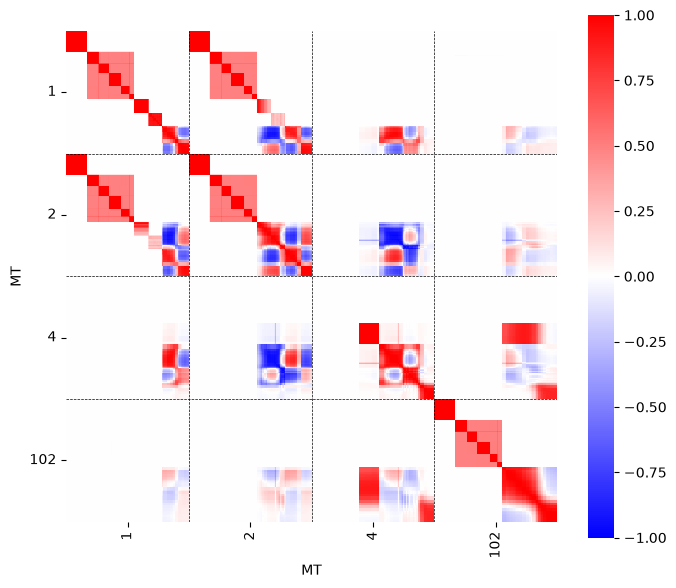

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

cov = cov1

n = cov.data.index.size

# number of groups
ng = (cov.data.index.get_level_values("MT") == 1).sum()

# number of reactions
nr = cov.data.index.get_level_values("MT").unique().size

data = cov.get_corr().data
data.index = data.index.get_level_values("MT")
data.columns = data.columns.get_level_values("MT")

sns.heatmap(data=data, vmin=-1, vmax=1, cmap="bwr", ax=ax)

# keep nr roughly spaced labels
ax.set_xticks(np.arange(ng // 2, n, ng))
ax.set_xticklabels(data.columns[::ng])

ax.set_yticks(np.arange(ng // 2, n, ng))
ax.set_yticklabels(data.index[::ng])

for i in range(1, nr):
    ax.axvline(ng * i, color="k", ls="--", lw=.5)
    ax.axhline(ng * i, color="k", ls="--", lw=.5)

ax.set_aspect("equal")
fig.tight_layout()

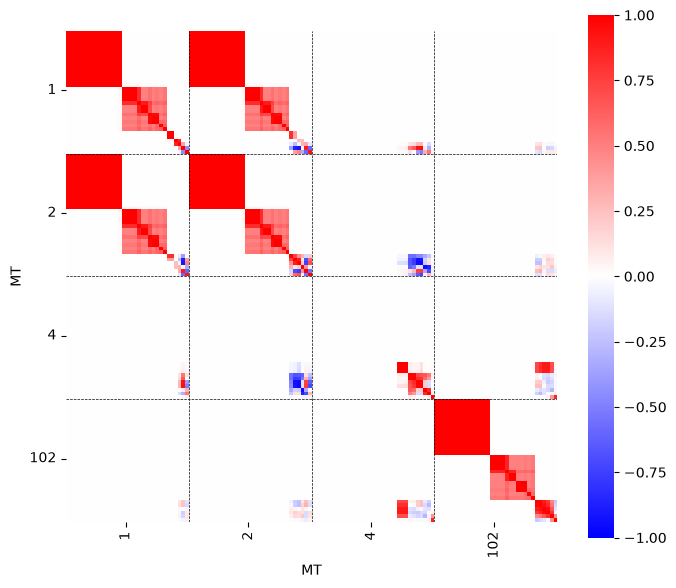

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))

cov = cov2

n = cov.data.index.size

# number of groups
ng = (cov.data.index.get_level_values("MT") == 1).sum()

# number of reactions
nr = cov.data.index.get_level_values("MT").unique().size

data = cov.get_corr().data
data.index = data.index.get_level_values("MT")
data.columns = data.columns.get_level_values("MT")

sns.heatmap(data=data, vmin=-1, vmax=1, cmap="bwr", ax=ax)

# keep nr roughly spaced labels
ax.set_xticks(np.arange(ng // 2, n, ng))
ax.set_xticklabels(data.columns[::ng])

ax.set_yticks(np.arange(ng // 2, n, ng))
ax.set_yticklabels(data.index[::ng])

for i in range(1, nr):
    ax.axvline(ng * i, color="k", ls="--", lw=.5)
    ax.axhline(ng * i, color="k", ls="--", lw=.5)

ax.set_aspect("equal")
fig.tight_layout()

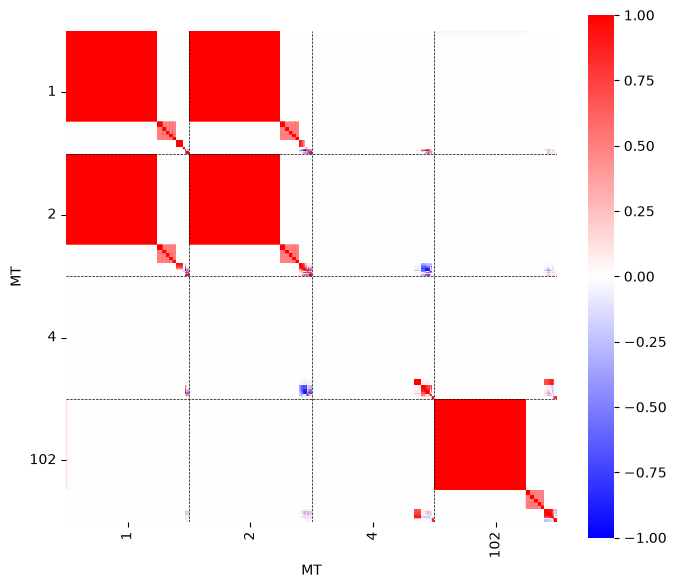

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))

cov = cov3

n = cov.data.index.size

# number of groups
ng = (cov.data.index.get_level_values("MT") == 1).sum()

# number of reactions
nr = cov.data.index.get_level_values("MT").unique().size

data = cov.get_corr().data
data.index = data.index.get_level_values("MT")
data.columns = data.columns.get_level_values("MT")

sns.heatmap(data=data, vmin=-1, vmax=1, cmap="bwr", ax=ax)

# keep nr roughly spaced labels
ax.set_xticks(np.arange(ng // 2, n, ng))
ax.set_xticklabels(data.columns[::ng])

ax.set_yticks(np.arange(ng // 2, n, ng))
ax.set_yticklabels(data.index[::ng])

for i in range(1, nr):
    ax.axvline(ng * i, color="k", ls="--", lw=.5)
    ax.axhline(ng * i, color="k", ls="--", lw=.5)

ax.set_aspect("equal")
fig.tight_layout()

## Plotting uncertainties

For the standard deviation we adopt only the right boundaries of the `IntervalIndex`.

In [13]:
std1 = cov1.get_std().multiply(100).reset_index().assign(ERIGHT=lambda x: x["E"].apply(lambda i: i.right))
std2 = cov2.get_std().multiply(100).reset_index().assign(ERIGHT=lambda x: x["E"].apply(lambda i: i.right))
std3 = cov3.get_std().multiply(100).reset_index().assign(ERIGHT=lambda x: x["E"].apply(lambda i: i.right))

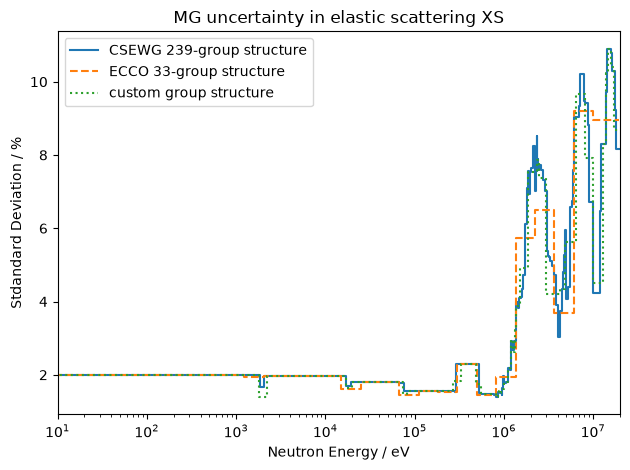

In [14]:
fig, ax = plt.subplots()
std1.query("MT==2").plot(x="ERIGHT", y="STD", ds="steps-pre", ax=ax, label="CSEWG 239-group structure")
std2.query("MT==2").plot(x="ERIGHT", y="STD", ds="steps-pre", ax=ax, ls="--", label="ECCO 33-group structure")
std3.query("MT==2").plot(x="ERIGHT", y="STD", ds="steps-pre", ax=ax, ls=":", label="custom group structure")
ax.set(xscale="log", xlim=(10, 2e7), ylabel="Stdandard Deviation / %", xlabel="Neutron Energy / eV", title="MG uncertainty in elastic scattering XS")
fig.tight_layout()

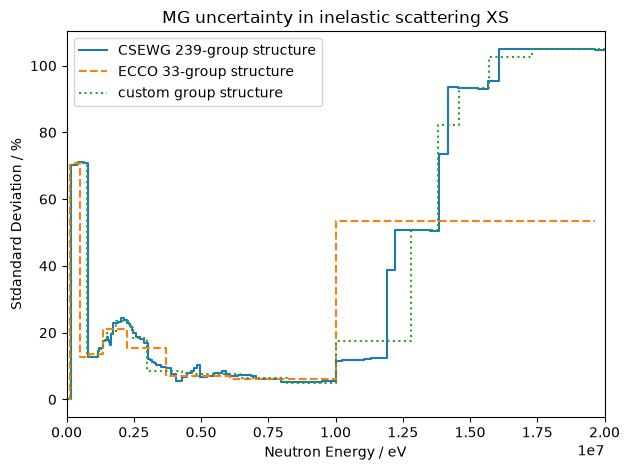

In [15]:
fig, ax = plt.subplots()
std1.query("MT==4").plot(x="ERIGHT", y="STD", ds="steps-pre", ax=ax, label="CSEWG 239-group structure")
std2.query("MT==4").plot(x="ERIGHT", y="STD", ds="steps-pre", ax=ax, ls="--", label="ECCO 33-group structure")
std3.query("MT==4").plot(x="ERIGHT", y="STD", ds="steps-pre", ax=ax, ls=":", label="custom group structure")
ax.set(xlim=(0, 2e7), ylabel="Stdandard Deviation / %", xlabel="Neutron Energy / eV", title="MG uncertainty in inelastic scattering XS")
fig.tight_layout()

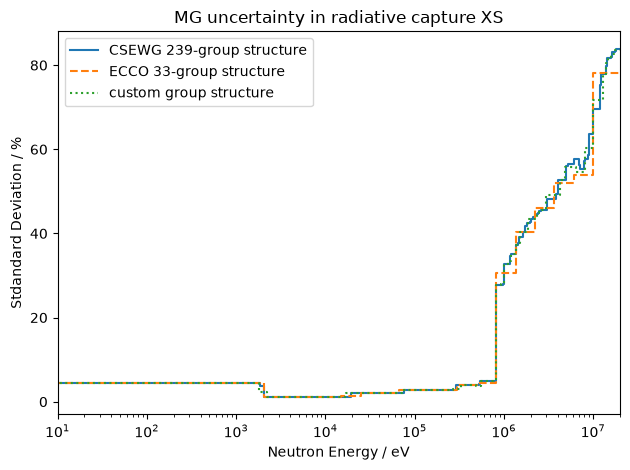

In [16]:
fig, ax = plt.subplots()
std1.query("MT==102").plot(x="ERIGHT", y="STD", ds="steps-pre", ax=ax, label="CSEWG 239-group structure")
std2.query("MT==102").plot(x="ERIGHT", y="STD", ds="steps-pre", ax=ax, ls="--", label="ECCO 33-group structure")
std3.query("MT==102").plot(x="ERIGHT", y="STD", ds="steps-pre", ax=ax, ls=":", label="custom group structure")
ax.set(xscale="log", xlim=(10, 2e7), ylabel="Stdandard Deviation / %", xlabel="Neutron Energy / eV", title="MG uncertainty in radiative capture XS")
fig.tight_layout()

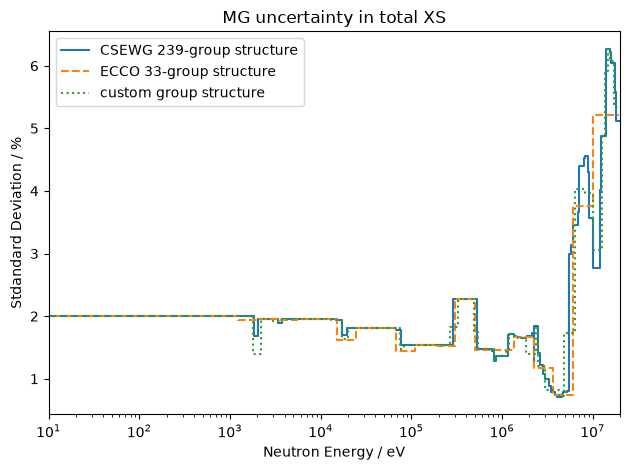

In [17]:
fig, ax = plt.subplots()
std1.query("MT==1").plot(x="ERIGHT", y="STD", ds="steps-pre", ax=ax, label="CSEWG 239-group structure")
std2.query("MT==1").plot(x="ERIGHT", y="STD", ds="steps-pre", ax=ax, ls="--", label="ECCO 33-group structure")
std3.query("MT==1").plot(x="ERIGHT", y="STD", ds="steps-pre", ax=ax, ls=":", label="custom group structure")
ax.set(xscale="log", xlim=(10, 2e7), ylabel="Stdandard Deviation / %", xlabel="Neutron Energy / eV", title="MG uncertainty in total XS")
fig.tight_layout()